In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import data, img_as_float, util, filters, morphology, measure, color
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops, regionprops_table
from scipy import ndimage as ndi
from skimage.segmentation import watershed

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, KMeans
from skimage.filters.rank import entropy
from skimage.morphology import disk

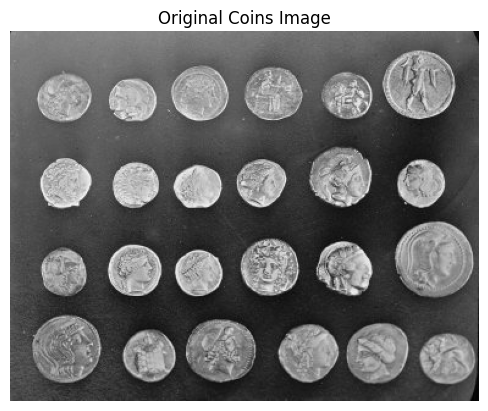

Image size: (303, 384)
Minimum grayscale level: 1
Maximum grayscale level: 252


In [67]:
coins = data.coins()

plt.imshow(coins, cmap='gray')
plt.title("Original Coins Image")
plt.axis("off")
plt.show()

print("Image size:", coins.shape)
print("Minimum grayscale level:", coins.min())
print("Maximum grayscale level:", coins.max())

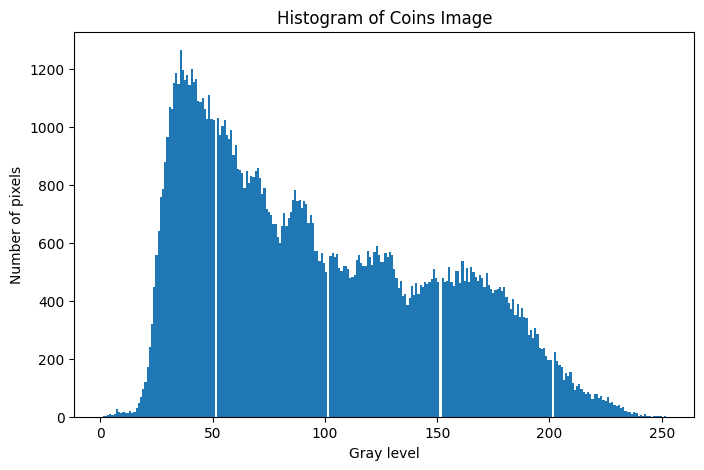

In [68]:
plt.figure(figsize=(8, 5))
plt.hist(coins.ravel(), bins=256)
plt.title("Histogram of Coins Image")
plt.xlabel("Gray level")
plt.ylabel("Number of pixels")
plt.show()

The darker pixels correspond mainly to the background and shadows, while the brighter pixels correspond mainly to the coins. The histogram peaks represent groups of pixels with similar grayscale intensity.

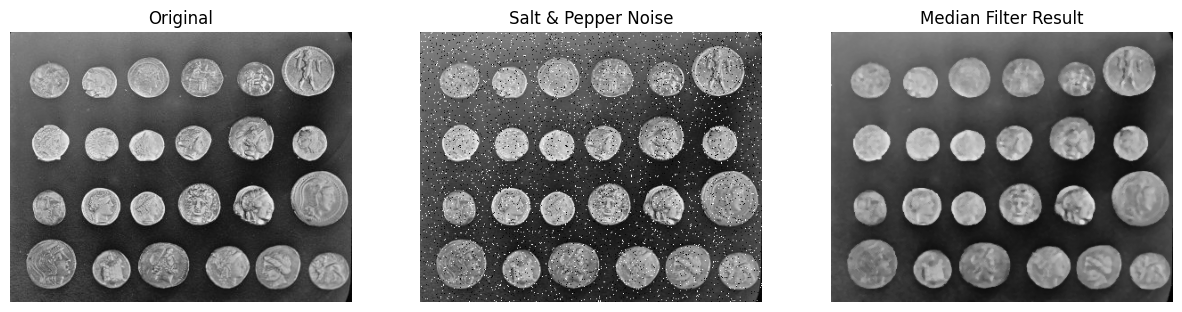

In [69]:
coins_float = img_as_float(coins)

noisy = util.random_noise(coins_float, mode='s&p', amount=0.05)
denoised = filters.median(noisy, footprint=disk(2))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(coins_float, cmap='gray')
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(noisy, cmap='gray')
ax[1].set_title("Salt & Pepper Noise")
ax[1].axis("off")

ax[2].imshow(denoised, cmap='gray')
ax[2].set_title("Median Filter Result")
ax[2].axis("off")

plt.show()

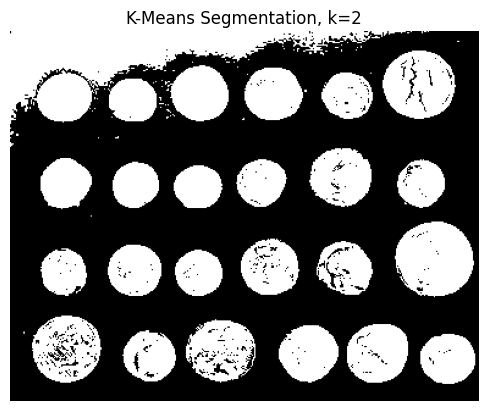

In [70]:
pixels = coins.reshape(-1, 1)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(pixels)

kmeans_segmented = kmeans_labels.reshape(coins.shape)

plt.imshow(kmeans_segmented, cmap='gray')
plt.title("K-Means Segmentation, k=2")
plt.axis("off")
plt.show()

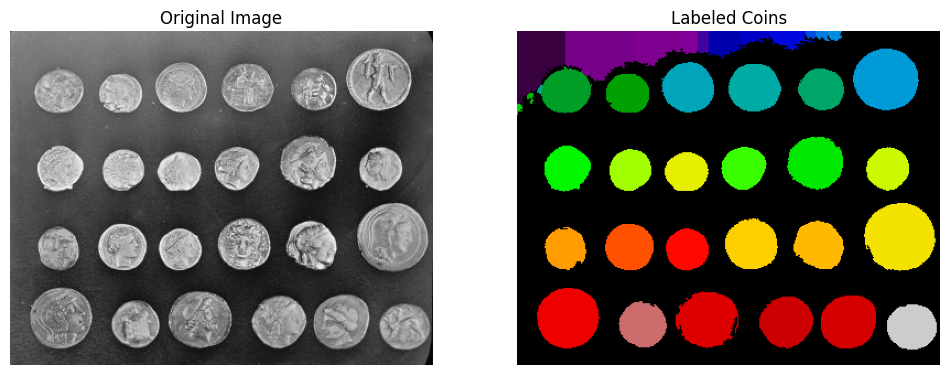

Number of coins: 32


In [71]:
threshold = threshold_otsu(coins)
binary = coins > threshold

binary = morphology.remove_small_objects(binary, min_size=100)
binary = morphology.remove_small_holes(binary, area_threshold=100)

distance = ndi.distance_transform_edt(binary)
local_max = morphology.local_maxima(distance)
markers = label(local_max)

labels_ws = watershed(-distance, markers, mask=binary)

regions = regionprops(labels_ws)
coin_regions = [r for r in regions if r.area > 100]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(coins, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(labels_ws, cmap='nipy_spectral')
ax[1].set_title("Labeled Coins")
ax[1].axis("off")

plt.show()

print("Number of coins:", len(coin_regions))

In [72]:
props = regionprops_table(
    labels_ws,
    intensity_image=coins,
    properties=[
        'label',
        'area',
        'axis_major_length',
        'orientation'
    ]
)

df = pd.DataFrame(props)

df = df[df['area'] > 100]

df.head()

,label,area,axis_major_length,orientation
0,1,2046.0,68.238237,-0.481715
1,2,2272.0,68.220849,-1.499443
2,3,1056.0,47.525708,-1.281601
3,4,294.0,22.958397,0.051947
4,5,195.0,22.566429,0.012694


In [73]:
print("Average area:", df['area'].mean())
print("Average major axis length:", df['axis_major_length'].mean())
print("Average orientation:", df['orientation'].mean())

Average area: 1436.25
Average major axis length: 45.11516920651827
Average orientation: -0.024509775877573324


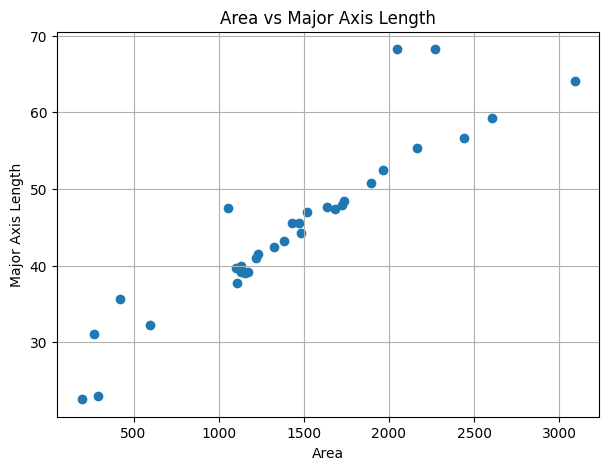

In [74]:
plt.figure(figsize=(7, 5))
plt.scatter(df['area'], df['axis_major_length'])
plt.title("Area vs Major Axis Length")
plt.xlabel("Area")
plt.ylabel("Major Axis Length")
plt.grid(True)
plt.show()

In [75]:
big_coins = df[df['area'] > 1750]

print("Number of coins with area > 1750:", len(big_coins))
big_coins

Number of coins with area > 1750: 8


,label,area,axis_major_length,orientation
0,1,2046.0,68.238237,-0.481715
1,2,2272.0,68.220849,-1.499443
11,12,2606.0,59.287480,1.525792
21,22,1895.0,50.775358,1.548946
27,28,3091.0,64.045624,1.354000
33,34,2438.0,56.688220,-1.162367
34,35,2166.0,55.359258,-1.351047
35,36,1965.0,52.540116,-1.002214


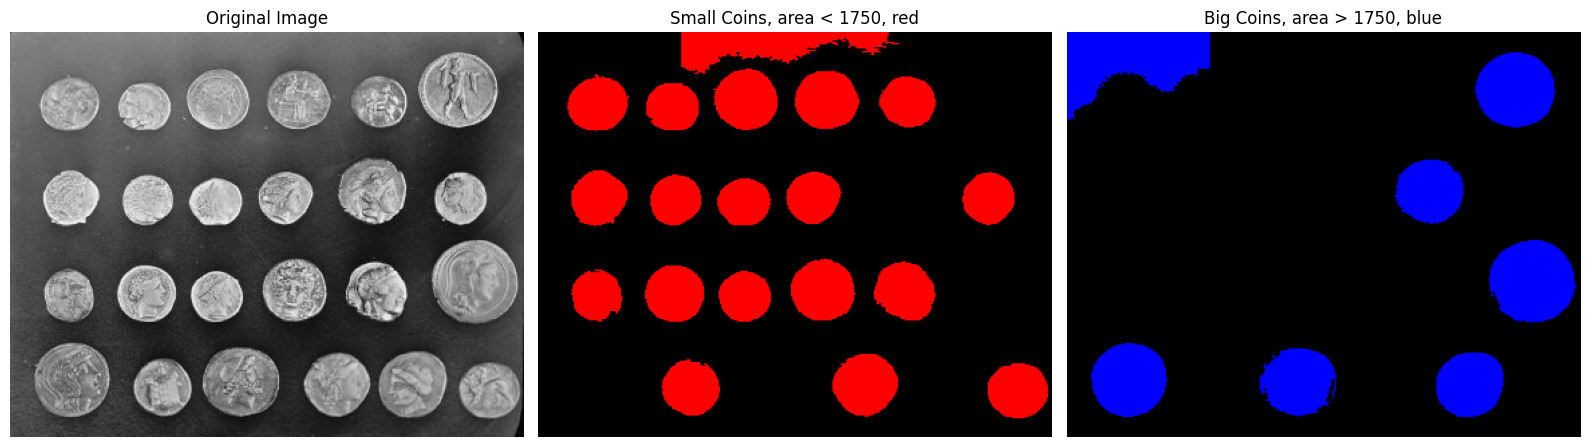

In [76]:
small_labels = df[df['area'] < 1750]['label'].values
big_labels = df[df['area'] > 1750]['label'].values

small_mask = np.isin(labels_ws, small_labels)
big_mask = np.isin(labels_ws, big_labels)

small_rgb = np.zeros((*coins.shape, 3))
big_rgb = np.zeros((*coins.shape, 3))

small_rgb[..., 0] = small_mask
big_rgb[..., 2] = big_mask

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].imshow(coins, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(small_rgb)
ax[1].set_title("Small Coins, area < 1750, red")
ax[1].axis("off")

ax[2].imshow(big_rgb)
ax[2].set_title("Big Coins, area > 1750, blue")
ax[2].axis("off")

plt.tight_layout()
plt.show()

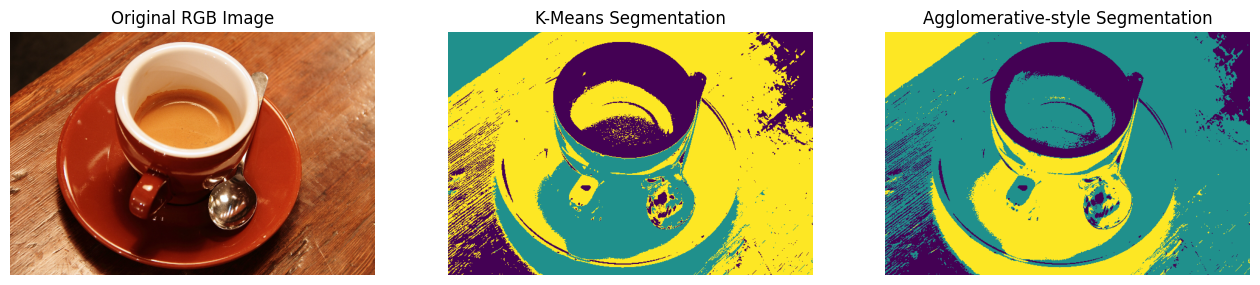

In [77]:
rgb_image = img_as_float(data.coffee())

h, w, c = rgb_image.shape
pixels_rgb = rgb_image.reshape(-1, 3)

sample_size = 8000
np.random.seed(42)
sample_idx = np.random.choice(pixels_rgb.shape[0], sample_size, replace=False)

sample_pixels = pixels_rgb[sample_idx]

agg = AgglomerativeClustering(n_clusters=3)
agg_sample_labels = agg.fit_predict(sample_pixels)

kmeans_rgb = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans_rgb.fit_predict(pixels_rgb)
kmeans_result = kmeans_labels.reshape(h, w)

agg_model = KMeans(n_clusters=3, random_state=1, n_init=10)
agg_model.fit(sample_pixels)
agg_result = agg_model.predict(pixels_rgb).reshape(h, w)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].imshow(rgb_image)
ax[0].set_title("Original RGB Image")
ax[0].axis("off")

ax[1].imshow(kmeans_result, cmap='viridis')
ax[1].set_title("K-Means Segmentation")
ax[1].axis("off")

ax[2].imshow(agg_result, cmap='viridis')
ax[2].set_title("Agglomerative-style Segmentation")
ax[2].axis("off")

plt.show()

The main steps for unsupervised RGB segmentation are: load the RGB image, reshape the image into a list of pixels, use the RGB values as features, apply an unsupervised clustering algorithm, reshape the predicted labels back to image size, and visualize the segmentation result.

K-Means separates pixels according to compact color clusters. Agglomerative clustering groups pixels hierarchically according to similarity. Both methods are unsupervised because they do not require labeled training data.

In [78]:
coins_uint = util.img_as_ubyte(coins)

entropy_img = entropy(coins_uint, disk(5))
gradient_img = filters.sobel(coins)

texture_features = {
    "mean_intensity": np.mean(coins),
    "std_intensity": np.std(coins),
    "mean_entropy": np.mean(entropy_img),
    "std_entropy": np.std(entropy_img),
    "mean_gradient": np.mean(gradient_img),
    "std_gradient": np.std(gradient_img)
}

texture_df = pd.DataFrame([texture_features])
texture_df

,mean_intensity,std_intensity,mean_entropy,std_entropy,mean_gradient,std_gradient
0,96.855516,52.879819,4.491211,0.864912,0.049193,0.076782


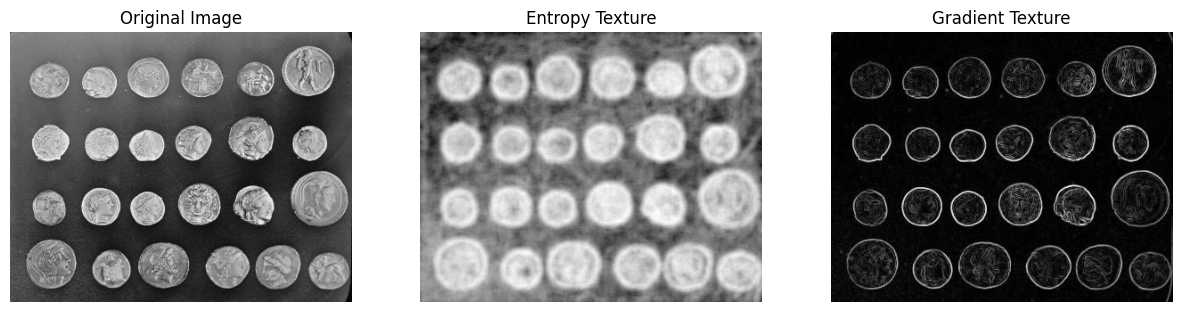

In [79]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(coins, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(entropy_img, cmap='gray')
ax[1].set_title("Entropy Texture")
ax[1].axis("off")

ax[2].imshow(gradient_img, cmap='gray')
ax[2].set_title("Gradient Texture")
ax[2].axis("off")

plt.show()

The main texture features extracted from the image are intensity statistics, entropy, and gradient magnitude. Mean and standard deviation describe the global grayscale distribution. Entropy measures local texture complexity. Gradient magnitude highlights local variations and edges.

Throughout this Computer Vision course, I gained practical experience in image analysis and processing using Python libraries such as scikit-image and matplotlib. I worked with techniques including image visualization, histogram analysis, filtering, segmentation, feature extraction, and basic image classification.

The course helped me understand how digital images can be analyzed as numerical data and how classical computer vision algorithms solve real image processing problems. The hands-on notebook approach made it easier to visualize and understand each processing step.

I also learned how to organize Computer Vision workflows in Google Colab and manage notebooks using GitHub. Overall, the course was practical, well-structured, and very helpful for understanding fundamental Computer Vision concepts.